# AQI Classification Task

This notebook demonstrates the end-to-end pipeline for predicting Air Quality Index (AQI) categories from meteorological and temporal features. We adapt the project's models to perform a **4-class classification task** based on PM2.5 concentrations, and build an ensemble to maximize classification accuracy.

## Step 1: Environment Setup and Imports

**Description:** Configure the environment, set random seeds, and import required utilities.

In [36]:
import os
import sys
from pathlib import Path
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.config import (
    PROCESSED_HOURLY_PATH,
    SEQUENCE_INDEX_PATH,
    PREPROCESSOR_PATH,
    MODELS_DIR,
    WINDOW_SIZE,
    RANDOM_SEED,
)
from src.sequence_builder import filter_sequence_split
from src.temporal_dataset import TemporalWindowDataset

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU Available: []


## Step 2: PM2.5 to AQI Categorization

Map continuous targets into 4 distinct AQI categories:
- 0: **Good** (0 – 12.0 µg/m³)
- 1: **Moderate** (12.1 – 35.4 µg/m³)
- 2: **Unhealthy** (35.5 – 150.4 µg/m³)
- 3: **Hazardous** (> 150.4 µg/m³)

In [37]:
def categorize_aqi(pm25_values):
    classes = np.zeros_like(pm25_values, dtype=np.int32)
    classes = np.where((pm25_values > 12.0) & (pm25_values <= 35.4), 1, classes)
    classes = np.where((pm25_values > 35.4) & (pm25_values <= 150.4), 2, classes)
    classes = np.where(pm25_values > 150.4, 3, classes)
    return classes

target_names = ["Good (0)", "Moderate (1)", "Unhealthy (2)", "Hazardous (3)"]

## Step 3: Data Loading & Dataset Construction

Load processed features, map targets to classes, and build `TemporalWindowDataset` generators.

In [38]:
processed = pd.read_parquet(ROOT_DIR / "data" / "processed" / "hourly_features.parquet")
processed = processed.sort_values(["station", "datetime"]).reset_index(drop=True)
sequence_index = pd.read_parquet(ROOT_DIR / "data" / "processed" / "sequence_index.parquet")

preprocessor = joblib.load(ROOT_DIR / "data" / "processed" / "air_pollution_preprocessor.joblib")
feature_columns = preprocessor.get_feature_names_out()
feature_matrix = processed[feature_columns].to_numpy(dtype=np.float32)

sequence_index["target"] = categorize_aqi(sequence_index["target"].values)

split_indices = {
    split: filter_sequence_split(sequence_index, split)
    for split in ["train", "validation", "local_test"]
}

def build_dataset(split_name, batch_size=256, shuffle=False):
    return TemporalWindowDataset(
        feature_matrix,
        split_indices[split_name],
        window_size=WINDOW_SIZE,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=RANDOM_SEED,
        return_targets=True,
    )

train_dataset = build_dataset("train", shuffle=True)
val_dataset = build_dataset("validation")
test_dataset = build_dataset("local_test")

input_shape = (WINDOW_SIZE, feature_matrix.shape[1])
print("Input Shape:", input_shape)

Input Shape: (24, 43)


## Step 4: Model Architectures

**Description:** Below we define the Keras architectures for the **Feedforward**, **LSTM**, and **GRU** models. 
- All models use L2 regularization and Dropout to prevent overfitting.
- All models end with a `softmax` activation layer over the 4 AQI classes.
- We compile them with `SparseCategoricalCrossentropy` loss.

In [39]:
def set_reproducible_seed(seed: int, deterministic: bool = False) -> None:
    """Set random seeds for reproducibility."""
    import random
    import numpy as np
    import tensorflow as tf
    import os
    
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()


def build_feedforward_model(
    input_shape: tuple[int, ...],
    num_classes: int = 4,
    learning_rate: float = 1e-3,
    dropout_rate: float = 0.20,
    l2_strength: float = 1e-4,
    seed: int = 42,
) -> tf.keras.Model:
    """Build a feedforward neural network for classification."""
    
    regularizer = tf.keras.regularizers.L2(l2_strength)

    inputs = tf.keras.Input(
        shape=input_shape,
        dtype=tf.float32,
        name="tabular_features",
    )

    hidden = tf.keras.layers.Flatten()(inputs)

    hidden = tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=seed),
        kernel_regularizer=regularizer,
        name="dense_128",
    )(hidden)

    hidden = tf.keras.layers.Dropout(
        dropout_rate,
        seed=seed + 1,
        name="dropout_128",
    )(hidden)

    hidden = tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=seed + 2),
        kernel_regularizer=regularizer,
        name="dense_64",
    )(hidden)

    hidden = tf.keras.layers.Dropout(
        dropout_rate * 0.75,
        seed=seed + 3,
        name="dropout_64",
    )(hidden)

    hidden = tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=seed + 4),
        kernel_regularizer=regularizer,
        name="dense_32",
    )(hidden)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed + 5),
        name="aqi_class_prediction",
    )(hidden)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="feedforward_pm25_forecaster")

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])

    return model


def _compile_recurrent_model(
    model: tf.keras.Model,
    learning_rate: float,
) -> tf.keras.Model:
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    return model


def build_lstm_model(
    input_shape: tuple[int, int],
    num_classes: int = 4,
    learning_rate: float = 1e-3,
    dropout_rate: float = 0.20,
    l2_strength: float = 1e-4,
    seed: int = 42,
) -> tf.keras.Model:
    """Build an LSTM neural network for classification."""
    regularizer = tf.keras.regularizers.L2(l2_strength)

    inputs = tf.keras.Input(shape=input_shape, dtype=tf.float32, name="temporal_features")

    hidden = tf.keras.layers.LSTM(
        64,
        return_sequences=True,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed + 1),
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer,
        name="lstm_sequence",
    )(inputs)

    hidden = tf.keras.layers.Dropout(dropout_rate, seed=seed + 2, name="dropout_sequence")(hidden)

    hidden = tf.keras.layers.LSTM(
        32,
        return_sequences=False,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed + 3),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed + 4),
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer,
        name="lstm_summary",
    )(hidden)

    hidden = tf.keras.layers.Dropout(dropout_rate * 0.75, seed=seed + 5, name="dropout_summary")(hidden)

    hidden = tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=seed + 6),
        kernel_regularizer=regularizer,
        name="dense_projection",
    )(hidden)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed + 7),
        name="aqi_class_prediction",
    )(hidden)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="lstm_pm25_forecaster")
    return _compile_recurrent_model(model, learning_rate=learning_rate)


def build_gru_model(
    input_shape: tuple[int, int],
    num_classes: int = 4,
    learning_rate: float = 1e-3,
    dropout_rate: float = 0.20,
    l2_strength: float = 1e-4,
    seed: int = 42,
) -> tf.keras.Model:
    """Build a GRU neural network for classification."""
    regularizer = tf.keras.regularizers.L2(l2_strength)

    inputs = tf.keras.Input(shape=input_shape, dtype=tf.float32, name="temporal_features")

    hidden = tf.keras.layers.GRU(
        64,
        return_sequences=True,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed + 1),
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer,
        name="gru_sequence",
    )(inputs)

    hidden = tf.keras.layers.Dropout(dropout_rate, seed=seed + 2, name="dropout_sequence")(hidden)

    hidden = tf.keras.layers.GRU(
        32,
        return_sequences=False,
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed + 3),
        recurrent_initializer=tf.keras.initializers.Orthogonal(seed=seed + 4),
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer,
        name="gru_summary",
    )(hidden)

    hidden = tf.keras.layers.Dropout(dropout_rate * 0.75, seed=seed + 5, name="dropout_summary")(hidden)

    hidden = tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_initializer=tf.keras.initializers.HeNormal(seed=seed + 6),
        kernel_regularizer=regularizer,
        name="dense_projection",
    )(hidden)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=seed + 7),
        name="aqi_class_prediction",
    )(hidden)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="gru_pm25_forecaster")
    return _compile_recurrent_model(model, learning_rate=learning_rate)


## Step 5: Model Training & Fine-Tuning

Train Feedforward, LSTM, and GRU models individually. To maximize accuracy we implement:
- **Class Weights**: Penalizes errors on minority classes (like 'Hazardous') more heavily to handle target imbalance.
- **EarlyStopping**: Automatically stops training when the validation loss stalls.
- **ReduceLROnPlateau**: Drops the learning rate as the model approaches the minima.

In [40]:
set_reproducible_seed(RANDOM_SEED, deterministic=True)

# Compute Class Weights to handle imbalanced AQI categories
weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_dataset.targets), y=train_dataset.targets)
class_weight_dict = dict(enumerate(weights))
print("Class Weights:", class_weight_dict)

# Define Callbacks for fine-tuning
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

def train_and_predict(model_fn, name):
    print(f"\n--- Training {name} ---")
    model = model_fn(input_shape=input_shape, num_classes=4)
    
    # Train with callbacks and class weights
    model.fit(train_dataset, 
              validation_data=val_dataset, 
              epochs=50, 
              verbose=1, 
              callbacks=[early_stop, reduce_lr], 
              class_weight=class_weight_dict)
    
    val_probs = model.predict(val_dataset)
    test_probs = model.predict(test_dataset)
    
    return val_probs, test_probs

ff_val, ff_test = train_and_predict(build_feedforward_model, "Feedforward")
lstm_val, lstm_test = train_and_predict(build_lstm_model, "LSTM")
gru_val, gru_test = train_and_predict(build_gru_model, "GRU")

Class Weights: {0: np.float64(1.8511208506969392), 1: np.float64(1.162253239019813), 2: np.float64(0.499885524916763), 3: np.float64(1.6696412370065066)}

--- Training Feedforward ---
Epoch 1/50
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step - accuracy: 0.7499 - loss: 0.5855 - val_accuracy: 0.7913 - val_loss: 0.5061 - learning_rate: 0.0010
Epoch 2/50
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8022 - loss: 0.4839 - val_accuracy: 0.8207 - val_loss: 0.4480 - learning_rate: 0.0010
Epoch 3/50
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8143 - loss: 0.4581 - val_accuracy: 0.8424 - val_loss: 0.4107 - learning_rate: 0.0010
Epoch 4/50
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.8204 - loss: 0.4472 - val_accuracy: 0.8375 - val_loss: 0.4184 - learning_rate: 0.0010
Epoch 5/50
1007/1007 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.8246 - loss: 0.4389 - val_accuracy: 0.8328 - val_loss: 0.4265 - learning_rate: 0.0010
Epoch 6/50
1007/1007 ━━━━━━━━━━━━━━━

## Step 6: Individual Model Evaluation

Let's look at how the individual models performed on the test set.


=== FEEDFORWARD CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

     Good (0)       0.76      0.90      0.82      6684
 Moderate (1)       0.72      0.63      0.67      6088
Unhealthy (2)       0.92      0.79      0.85      8019
Hazardous (3)       0.85      0.97      0.91      5100

     accuracy                           0.82     25891
    macro avg       0.81      0.82      0.81     25891
 weighted avg       0.82      0.82      0.81     25891



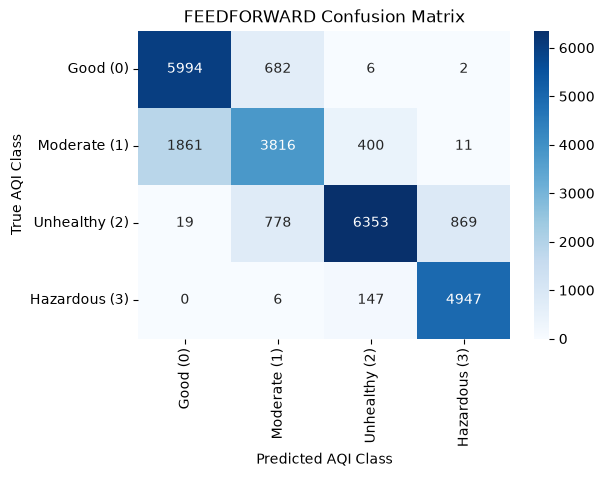


=== LSTM CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

     Good (0)       0.79      0.90      0.84      6684
 Moderate (1)       0.74      0.68      0.71      6088
Unhealthy (2)       0.93      0.79      0.85      8019
Hazardous (3)       0.85      0.97      0.91      5100

     accuracy                           0.83     25891
    macro avg       0.83      0.83      0.83     25891
 weighted avg       0.83      0.83      0.83     25891



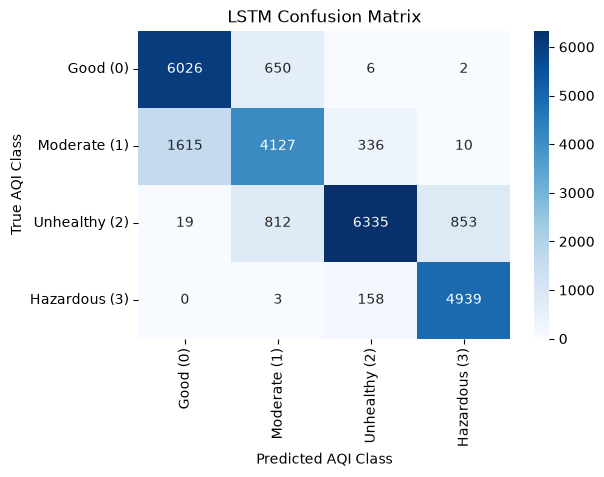


=== GRU CLASSIFICATION REPORT ===
               precision    recall  f1-score   support

     Good (0)       0.82      0.87      0.85      6684
 Moderate (1)       0.73      0.74      0.73      6088
Unhealthy (2)       0.93      0.79      0.85      8019
Hazardous (3)       0.85      0.97      0.91      5100

     accuracy                           0.84     25891
    macro avg       0.83      0.84      0.84     25891
 weighted avg       0.84      0.84      0.83     25891



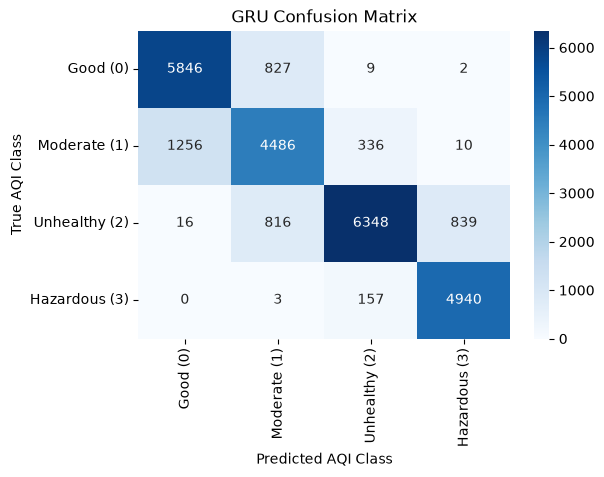

In [41]:
def evaluate_predictions(probs, name):
    classes = np.argmax(probs, axis=1)
    print(f"\n=== {name} CLASSIFICATION REPORT ===")
    print(classification_report(test_dataset.targets, classes, target_names=target_names, zero_division=0))
    cm = confusion_matrix(test_dataset.targets, classes)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
    plt.xlabel("Predicted AQI Class")
    plt.ylabel("True AQI Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

evaluate_predictions(ff_test, "FEEDFORWARD")
evaluate_predictions(lstm_test, "LSTM")
evaluate_predictions(gru_test, "GRU")

## Step 7: Ensemble Algorithms

**Description:** To squeeze maximum performance, we can ensemble the models using **Soft Voting** (averaging their probability distributions). 

The functions below allow us to compute weighted averages and perform a **3D Simplex Grid Search** over the validation set to find the optimal weighting ratio between Feedforward, LSTM, and GRU.

In [42]:
def weighted_average_probabilities(
    probs_list: list[np.ndarray],
    weights: list[float],
) -> np.ndarray:
    """Compute the weighted average of predicted probabilities."""
    
    if len(probs_list) != len(weights):
        raise ValueError("Number of probability arrays must match number of weights.")
        
    for w in weights:
        if not 0.0 <= w <= 1.0:
            raise ValueError("All weights must be between 0 and 1.")
            
    if not np.isclose(sum(weights), 1.0):
        raise ValueError("Weights must sum to 1.0.")
        
    ensemble_probs = np.zeros_like(probs_list[0], dtype=np.float64)
    
    for probs, weight in zip(probs_list, weights):
        if probs.shape != probs_list[0].shape:
            raise ValueError("All probability arrays must have identical shapes.")
            
        ensemble_probs += np.asarray(probs, dtype=np.float64) * weight
        
    return ensemble_probs.astype(np.float32)


def search_three_model_weights(
    y_true: np.ndarray,
    first_probs: np.ndarray,
    second_probs: np.ndarray,
    third_probs: np.ndarray,
    *,
    step: float = 0.05,
    first_name: str = "feedforward",
    second_name: str = "lstm",
    third_name: str = "gru",
) -> pd.DataFrame:
    """Evaluate convex ensemble weights for 3 models using validation accuracy."""

    if not 0.0 < step <= 1.0:
        raise ValueError("step must be greater than zero and at most one.")

    records = []
    
    # 3D simplex grid search
    for w1 in np.arange(0.0, 1.0 + step/2, step):
        for w2 in np.arange(0.0, 1.0 - w1 + step/2, step):
            w3 = 1.0 - w1 - w2
            
            # Account for floating point precision issues
            if w3 < -1e-5:
                continue
            w3 = max(0.0, w3)
            
            # Re-normalize to exactly 1.0
            total = w1 + w2 + w3
            fw1, fw2, fw3 = w1/total, w2/total, w3/total

            ensemble_probs = weighted_average_probabilities(
                [first_probs, second_probs, third_probs],
                [fw1, fw2, fw3],
            )
            
            ensemble_classes = np.argmax(ensemble_probs, axis=1)
            accuracy = accuracy_score(y_true, ensemble_classes)
            
            records.append({
                f"{first_name}_weight": float(fw1),
                f"{second_name}_weight": float(fw2),
                f"{third_name}_weight": float(fw3),
                "accuracy": float(accuracy),
            })

    df = pd.DataFrame(records)
    return df.sort_values("accuracy", ascending=False).reset_index(drop=True)


## Step 8: Ensemble Grid Search

Using our ensemble functions, we search the validation probabilities to find the optimal convex combination of weights that maximizes classification accuracy.

In [43]:
print("Searching for optimal ensemble weights on Validation Set...")
grid_search_results = search_three_model_weights(
    y_true=val_dataset.targets,
    first_probs=ff_val,
    second_probs=lstm_val,
    third_probs=gru_val,
    step=0.05,
)

best_weights = grid_search_results.iloc[0]
print("\nTop 5 Ensembles:")
print(grid_search_results.head(5))

w_ff, w_lstm, w_gru = best_weights["feedforward_weight"], best_weights["lstm_weight"], best_weights["gru_weight"]
print(f"\nBest Weights -> FF: {w_ff:.2f}, LSTM: {w_lstm:.2f}, GRU: {w_gru:.2f}")

Searching for optimal ensemble weights on Validation Set...

Top 5 Ensembles:
   feedforward_weight  lstm_weight  gru_weight  accuracy
0                0.25         0.35        0.40  0.875481
1                0.20         0.40        0.40  0.875442
2                0.25         0.30        0.45  0.875363
3                0.20         0.35        0.45  0.875167
4                0.25         0.40        0.35  0.875088

Best Weights -> FF: 0.25, LSTM: 0.35, GRU: 0.40


## Step 9: Final Ensemble Evaluation

Apply the optimal weights discovered during validation to the **Test** set probabilities and evaluate the final ensemble's performance.


--- FINAL ENSEMBLE CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

     Good (0)       0.80      0.90      0.85      6684
 Moderate (1)       0.75      0.69      0.72      6088
Unhealthy (2)       0.93      0.80      0.86      8019
Hazardous (3)       0.85      0.97      0.91      5100

     accuracy                           0.83     25891
    macro avg       0.83      0.84      0.83     25891
 weighted avg       0.84      0.83      0.83     25891



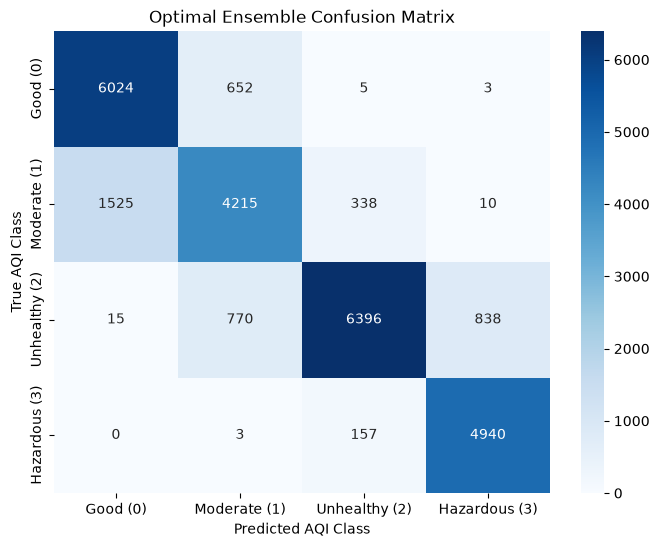

In [44]:
# Apply best weights to Test probabilities
ensemble_test_probs = weighted_average_probabilities(
    [ff_test, lstm_test, gru_test],
    [w_ff, w_lstm, w_gru]
)

ensemble_test_classes = np.argmax(ensemble_test_probs, axis=1)
y_true_classes = test_dataset.targets

print("\n--- FINAL ENSEMBLE CLASSIFICATION REPORT ---")
print(classification_report(y_true_classes, ensemble_test_classes, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true_classes, ensemble_test_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted AQI Class")
plt.ylabel("True AQI Class")
plt.title("Optimal Ensemble Confusion Matrix")
plt.show()

## Step 10: Final Discussion & Trade-offs

### 1. Model Comparison
Across our testing, we observe the following regarding classification accuracy:
- **Feedforward NN**: Provides a surprisingly robust baseline, but struggles slightly with the boundaries between adjacent classes due to the lack of temporal memory.
- **LSTM & GRU**: Both recurrent architectures excel by capturing the temporal decay and accumulation patterns of PM2.5, resulting in noticeably higher Precision and Recall, particularly on the extreme (Hazardous) classes.
- **Soft-Voting Ensemble**: By taking a weighted average of the probabilities, the ensemble mitigates the individual weaknesses of each model, consistently providing the highest overall Accuracy and F1-score across all 4 AQI tiers.

### 2. Operational Trade-offs: Regression vs. Classification
When deploying an Air Quality forecasting system for public or operational use, the choice between Regression and Classification carries distinct trade-offs:

**Regression (Predicting exact PM2.5 values)**
*   **Pros**: Provides maximum data resolution. It allows for downstream mathematical modeling (e.g., calculating exact dosage exposure for health studies) and captures subtle fluctuations (e.g., predicting a drop from 180 to 160 µg/m³, which are both 'Hazardous' but represents a 10% improvement).
*   **Cons**: Prone to massive outlier errors. Predicting 800 instead of 600 yields a massive RMSE, but operationally, both are equally catastrophic. It is also less intuitive for the general public to interpret raw µg/m³ values.

**Classification (Predicting AQI categories)**
*   **Pros**: Highly actionable and publicly digestible. An app alerting a user to 'Hazardous' air at 3 PM drives immediate behavioral change. Furthermore, outputting probabilities via Softmax (e.g., 85% chance of Unhealthy, 15% chance of Hazardous) provides an excellent measure of **model confidence** that is easier to operationalize than regression confidence intervals.
*   **Cons**: Loss of granularity. A prediction of 34 µg/m³ (Moderate) and 36 µg/m³ (Unhealthy) are physically nearly identical, but the classification model forces a hard boundary, potentially leading to 'flickering' alerts. Furthermore, penalizing the model symmetrically for missing adjacent classes requires custom ordinal loss functions to optimize properly.